# Part 1 — Theory: Eigenvalues, Eigenvectors and PCA

## 1. Introduction

Eigenvalues and eigenvectors are among the most important concepts in linear algebra, and they sit at the mathematical heart of many machine-learning algorithms. They allow us to look at a square matrix not as an opaque table of numbers but as a *transformation*, and to identify the special directions along which that transformation behaves in the simplest possible way: pure stretching or shrinking, with no rotation. **Principal Component Analysis (PCA)**, the most widely used technique for dimensionality reduction, is a direct application of eigenvalue decomposition applied to the covariance matrix of the data.

## 2. Definition

Let $A$ be an $n \times n$ square matrix. A non-zero vector $v$ is called an **eigenvector** of $A$ if multiplying $A$ by $v$ produces a vector that points in the same direction as $v$ itself, scaled by a number $\lambda$:

$$A \cdot v = \lambda \cdot v$$

Here $\lambda$ is a scalar called the **eigenvalue** corresponding to the eigenvector $v$. In words: when the matrix $A$ acts on its eigenvector $v$, the result is the same vector $v$ simply stretched (or compressed, or flipped) by a factor of $\lambda$. The direction of $v$ does not change.

### Geometric intuition

A general matrix transformation rotates, stretches and skews vectors in different directions all at once. Eigenvectors are the special axes along which the transformation has *no rotation component* — only scaling. The eigenvalue $\lambda$ tells you how much scaling happens:

- If $\lambda > 1$, the eigenvector is stretched.
- If $0 < \lambda < 1$, it is compressed.
- If $\lambda < 0$, it is flipped (reflected) and scaled.
- If $\lambda = 0$, it is collapsed to the origin (the matrix is singular along that direction).

## 3. How to Compute Them

Eigenvalues are found by solving the **characteristic equation**:

$$\det(A - \lambda I) = 0$$

where $I$ is the identity matrix and $\det(\cdot)$ is the determinant. This gives a polynomial in $\lambda$ whose roots are the eigenvalues. Substituting each eigenvalue back into $(A - \lambda I)v = 0$ and solving the resulting linear system gives the corresponding eigenvector.

## 4. Worked Example

Consider the $2 \times 2$ matrix:

$$A = \begin{bmatrix} 4 & 1 \\ 2 & 3 \end{bmatrix}$$

**Step 1 — characteristic equation:**

$$\det(A - \lambda I) = \det\begin{bmatrix} 4-\lambda & 1 \\ 2 & 3-\lambda \end{bmatrix} = (4-\lambda)(3-\lambda) - (1)(2) = \lambda^2 - 7\lambda + 10 = 0$$

**Step 2 — solve for $\lambda$:**

$$\lambda^2 - 7\lambda + 10 = 0 \;\Rightarrow\; (\lambda - 5)(\lambda - 2) = 0 \;\Rightarrow\; \lambda_1 = 5,\; \lambda_2 = 2$$

**Step 3 — eigenvectors.** For $\lambda_1 = 5$, solve $(A - 5I)v = 0$:

$$\begin{bmatrix} -1 & 1 \\ 2 & -2 \end{bmatrix}\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix} \;\Rightarrow\; -x + y = 0 \;\Rightarrow\; y = x \;\Rightarrow\; v_1 = \begin{bmatrix} 1 \\ 1 \end{bmatrix}$$

For $\lambda_2 = 2$, solve $(A - 2I)v = 0$:

$$\begin{bmatrix} 2 & 1 \\ 2 & 1 \end{bmatrix}\begin{bmatrix} x \\ y \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \end{bmatrix} \;\Rightarrow\; 2x + y = 0 \;\Rightarrow\; v_2 = \begin{bmatrix} 1 \\ -2 \end{bmatrix}$$

So the matrix $A$ stretches anything along $[1, 1]^T$ by a factor of $5$, and along $[1, -2]^T$ by a factor of $2$.

## 5. Important Properties

- An $n \times n$ matrix has at most $n$ eigenvalues (counted with multiplicity).
- The **sum** of all eigenvalues equals the **trace** of the matrix (sum of diagonal entries).
- The **product** of all eigenvalues equals the **determinant** of the matrix.
- **Symmetric matrices** ($A = A^T$) always have **real eigenvalues**, and their eigenvectors corresponding to distinct eigenvalues are **orthogonal**. This property is what makes PCA work cleanly.
- If $\lambda = 0$ is an eigenvalue, the matrix is singular (non-invertible).

## 6. A Second Example — Identity and Diagonal Matrices

For the identity matrix $I$, every non-zero vector is an eigenvector with eigenvalue $1$, because $I \cdot v = 1 \cdot v$ for all $v$. For a diagonal matrix:

$$D = \begin{bmatrix} 3 & 0 \\ 0 & 7 \end{bmatrix}$$

the eigenvalues are simply the diagonal entries ($3$ and $7$), and the eigenvectors are the standard basis vectors $[1, 0]^T$ and $[0, 1]^T$. Diagonal matrices are the simplest possible transformations — pure axis-aligned scaling — and eigendecomposition is, in essence, the search for a basis in which a general matrix *looks* diagonal.

## 7. Role in Principal Component Analysis (PCA)

PCA is a technique for reducing the dimensionality of a dataset while preserving as much of its variance as possible. It rests entirely on eigenvalue decomposition. The recipe is as follows.

### Step 1 — Standardize the data
Subtract the mean of each feature (mean-centering) and, if features are on different scales, divide by the standard deviation. This produces a centered data matrix $X$ of shape (n_samples, n_features).

### Step 2 — Compute the covariance matrix
The covariance matrix $C$ captures how features vary together:

$$C = \frac{1}{n - 1} \, X^T X$$

$C$ is square ($d \times d$, where $d$ is the number of features), **symmetric**, and **positive semi-definite**. Symmetry guarantees that all its eigenvalues are real and its eigenvectors are mutually orthogonal — exactly the properties PCA needs.

### Step 3 — Eigendecomposition of the covariance matrix
Solve $C \cdot v = \lambda \cdot v$. The eigenvectors $v_1, v_2, \ldots, v_d$ are called the **principal components**, and the eigenvalues $\lambda_1, \lambda_2, \ldots, \lambda_d$ are the **variances** of the data along those components.

### Step 4 — Sort by eigenvalue and pick the top k
Sort eigenvalues in descending order. The first eigenvector (corresponding to the largest eigenvalue) is the direction of **maximum variance** in the data. The second is the direction of next-largest variance, orthogonal to the first, and so on. Choosing the top $k$ eigenvectors and projecting the data onto them gives a $k$-dimensional representation that retains the largest possible fraction of the total variance.

### Step 5 — Compute the explained variance ratio

$$\text{explained\_variance\_ratio}_i = \frac{\lambda_i}{\sum_j \lambda_j}$$

This tells you what fraction of the total variance each principal component captures. A common rule of thumb is to keep enough components so that the cumulative explained variance exceeds 90–95%.

## 8. Why Eigenvectors of the Covariance Matrix Are the Right Directions

PCA is formulated as: find a unit vector $w$ that maximizes $\text{Var}(Xw)$, the variance of the data projected onto $w$. Writing this out:

$$\text{Var}(Xw) = w^T C w \quad \text{subject to} \quad w^T w = 1$$

This is a constrained optimisation problem. Using **Lagrange multipliers**, the solution satisfies $C w = \lambda w$ — exactly the eigenvalue equation. The maximizing $w$ is therefore the eigenvector of $C$ with the largest eigenvalue, and that maximum value *is* $\lambda$ itself. So the eigenvectors of $C$ are not just convenient — they are mathematically the unique directions that maximize captured variance.

## 9. Concrete PCA Walkthrough

Suppose we have a small dataset with two features (height in cm, weight in kg) for several people. After mean-centering, the covariance matrix might look like:

$$C = \begin{bmatrix} 26.0 & 18.5 \\ 18.5 & 15.2 \end{bmatrix}$$

Solving $\det(C - \lambda I) = 0$ gives two eigenvalues, say $\lambda_1 = 39.8$ and $\lambda_2 = 1.4$. The total variance is $41.2$.

- **PC1** explains $39.8 / 41.2 \approx 96.6\%$ of variance — height and weight are highly correlated, so most of the spread lies along a single diagonal direction.
- **PC2** explains only $3.4\%$ of variance — the residual scatter perpendicular to that diagonal.

Reducing from two dimensions to one (keeping only PC1) loses just $3.4\%$ of the information. This is exactly the kind of compression PCA is designed for.

## 10. Summary

- An eigenvector of a matrix is a direction that the matrix only *scales* (does not rotate). The eigenvalue is the scaling factor.
- Eigenvalues are roots of $\det(A - \lambda I) = 0$; eigenvectors are then found from $(A - \lambda I)v = 0$.
- Symmetric matrices have real eigenvalues and orthogonal eigenvectors — covariance matrices are symmetric, which is what makes PCA well-posed.
- In PCA, the eigenvectors of the covariance matrix are the principal components, and the eigenvalues are the variances along them.
- Ordering principal components by eigenvalue and keeping the top $k$ yields the **optimal $k$-dimensional approximation** of the data in the least-squared-error sense.
- Eigen-decomposition therefore turns the abstract goal of "reduce dimensions while keeping the most information" into a concrete, solvable linear-algebra problem.

---

# Part 2 — Students' Social Network Profile Clustering

**Goal:** segment ~15,000 high-school students by their interests, demographics and graduation cohort, and compare three clustering algorithms (K-Means, Hierarchical, DBSCAN) by silhouette score.

> **Data file required:** `03_Clustering_Marketing.csv` in the same folder as this notebook.

The original Part 2 notebook starts here. The first cell of that notebook was its own title; we skip it and append everything else.

## 1. Imports & Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 60)
np.random.seed(42)

## 2. Load the Data

In [3]:
df = pd.read_csv("03_Clustering_Marketing.csv")
print("Shape:", df.shape)
df.head()

Shape: (15000, 40)


,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,cute,sex,sexy,hot,kissed,dance,band,marching,music,rock,god,church,jesus,bible,hair,dress,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0,0,0,0,1,2,0,1,0,0,4,0,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,0,0,3,0,6,0,2,0,0,0,0,0,1,0,1,1,0,0,5,0,0,0,0,3,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gradyear         15000 non-null  int64 
 1   gender           13663 non-null  object
 2   age              12504 non-null  object
 3   NumberOffriends  15000 non-null  int64 
 4   basketball       15000 non-null  int64 
 5   football         15000 non-null  int64 
 6   soccer           15000 non-null  int64 
 7   softball         15000 non-null  int64 
 8   volleyball       15000 non-null  int64 
 9   swimming         15000 non-null  int64 
 10  cheerleading     15000 non-null  int64 
 11  baseball         15000 non-null  int64 
 12  tennis           15000 non-null  int64 
 13  sports           15000 non-null  int64 
 14  cute             15000 non-null  int64 
 15  sex              15000 non-null  int64 
 16  sexy             15000 non-null  int64 
 17  hot              15000 non-null

The dataset has **15,000 rows × 40 columns**:
- 4 demographic columns: `gradyear`, `gender`, `age`, `NumberOffriends`
- 36 binary/count columns counting how often each interest keyword appears in the student's profile (sports, music, religion, fashion, romantic, antisocial themes, etc.)

## 3. Data Cleaning

### 3.1 Missing values

In [5]:
missing = df.isnull().sum()
missing[missing > 0]

gender    1337
age       2496
dtype: int64

### 3.2 The `age` column has Excel-corrupted values

In [6]:
# Some age cells were auto-formatted by Excel into German dates like "16. Jun".
# Coerce non-numeric to NaN — they will be treated as missing.
print("Sample of bad age values:", df.loc[pd.to_numeric(df['age'], errors='coerce').isna() & df['age'].notna(), 'age'].unique()[:10])
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Restrict age to a plausible high-school range (13–20). Anything outside is set to NaN.
df.loc[(df['age'] < 13) | (df['age'] > 20), 'age'] = np.nan
print("\nAge after cleaning:")
print(df['age'].describe())

Sample of bad age values: ['18. Jul' '17. Jun' '15. Mai' '16. Feb' '18. Apr' '17. Jul' '16. Jun'
 '18. Mai' '16. Dez' '16. Apr']

Age after cleaning:
count    12020.000000
mean        17.261258
std          1.156884
min         13.027000
25%         16.323000
50%         17.273000
75%         18.229000
max         19.995000
Name: age, dtype: float64


### 3.3 Impute missing values

In [7]:
# Numerical: impute age with the median age within each graduation year (more accurate than a global median).
df['age'] = df.groupby('gradyear')['age'].transform(lambda s: s.fillna(s.median()))
# Any rows still missing get the overall median.
df['age'] = df['age'].fillna(df['age'].median())

# Categorical: gender — fill with 'Unknown' to preserve those rows as a separate group.
df['gender'] = df['gender'].fillna("Unknown")

# Confirm no missing values remain.
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


## 4. Exploratory Data Analysis

### 4.1 Demographics

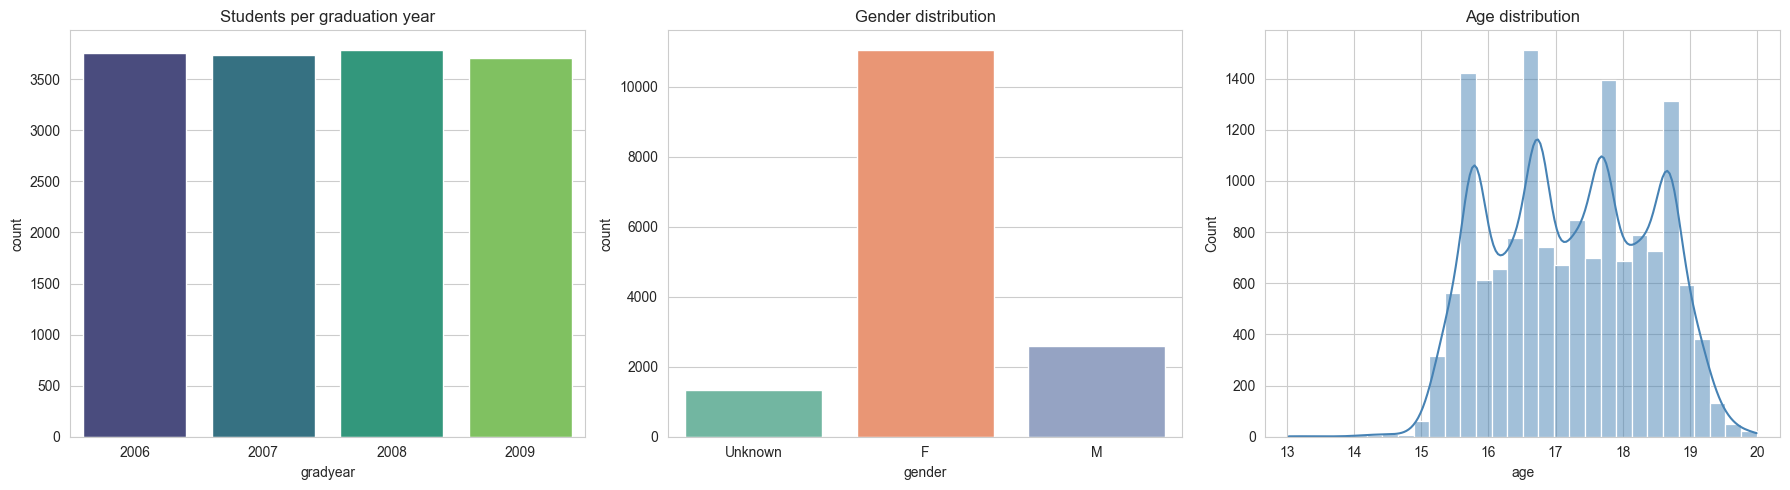

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='gradyear', data=df, ax=ax[0], palette="viridis")
ax[0].set_title("Students per graduation year")

sns.countplot(x='gender', data=df, ax=ax[1], palette="Set2")
ax[1].set_title("Gender distribution")

sns.histplot(df['age'], bins=30, kde=True, ax=ax[2], color="steelblue")
ax[2].set_title("Age distribution")
plt.tight_layout(); plt.show()

**Observations:** the four graduation cohorts (2006–2009) are roughly balanced; females outnumber males ~4:1; ages cluster between 15 and 19 as expected for a high-school sample.

### 4.2 Number of friends

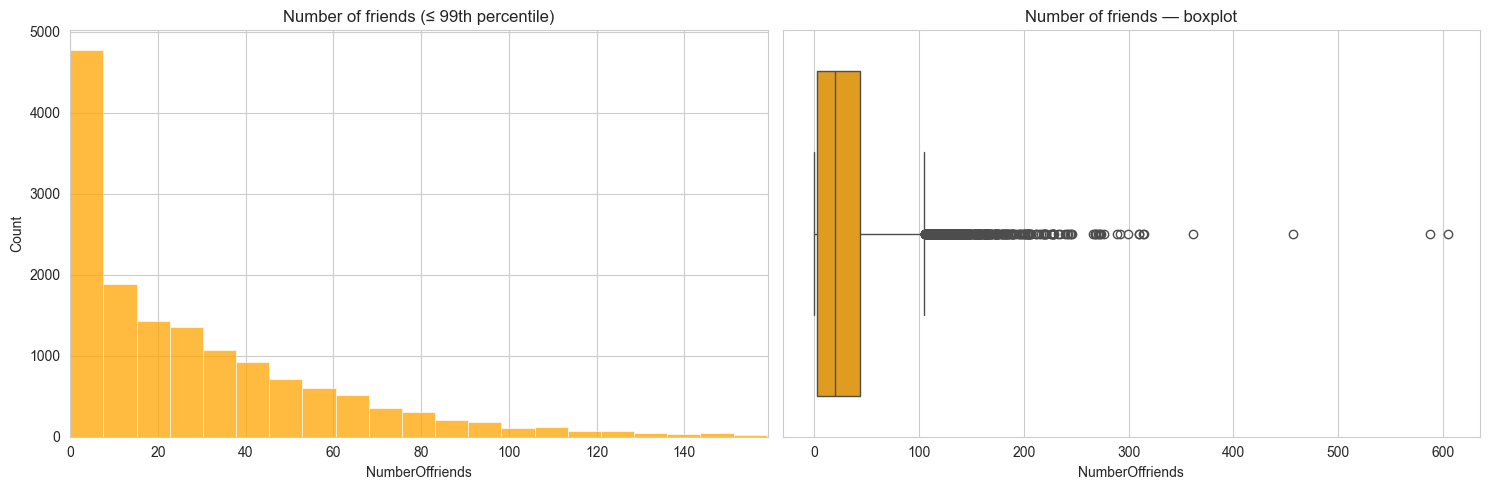

count    15000.000000
mean        29.834533
std         35.386649
min          0.000000
25%          3.000000
50%         20.000000
75%         44.000000
max        605.000000
Name: NumberOffriends, dtype: float64


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['NumberOffriends'], bins=80, ax=ax[0], color="orange")
ax[0].set_xlim(0, df['NumberOffriends'].quantile(0.99))
ax[0].set_title("Number of friends (≤ 99th percentile)")

sns.boxplot(x=df['NumberOffriends'], ax=ax[1], color="orange")
ax[1].set_title("Number of friends — boxplot")
plt.tight_layout(); plt.show()
print(df['NumberOffriends'].describe())

Heavily right-skewed: most students have a small social circle while a few have huge ones. Will need a log transformation.

### 4.3 Top interest keywords

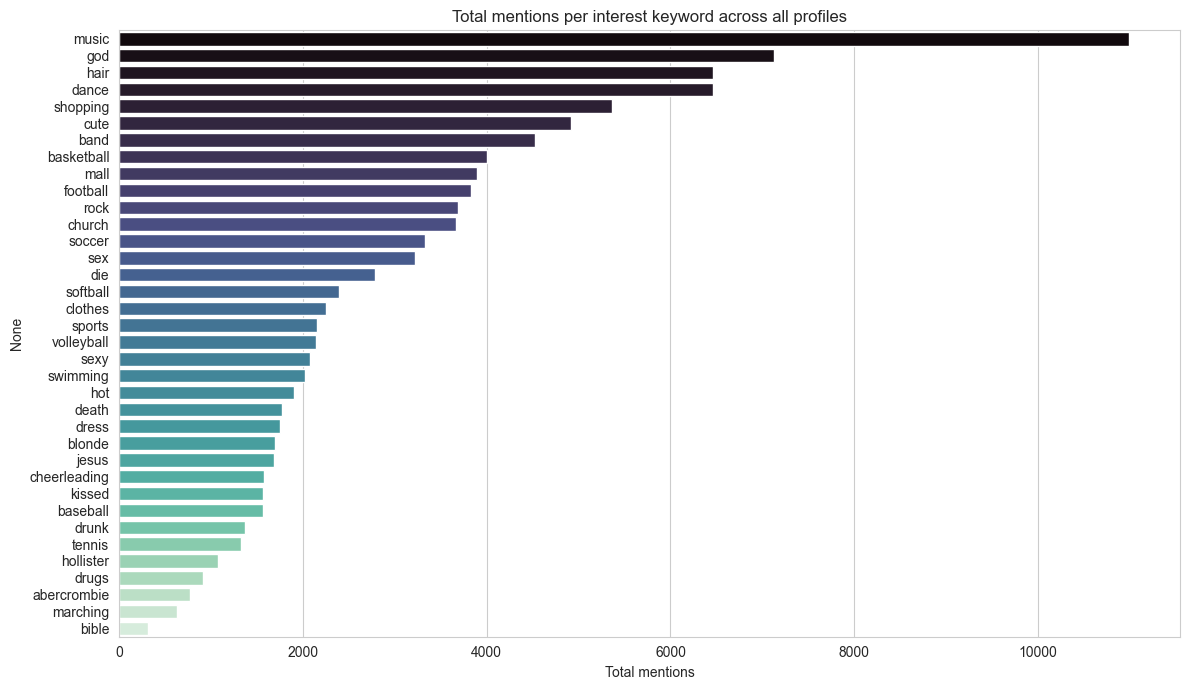

In [11]:
interest_cols = df.columns[4:]   # all 36 keyword columns
totals = df[interest_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=totals.values, y=totals.index, palette="mako")
plt.title("Total mentions per interest keyword across all profiles")
plt.xlabel("Total mentions"); plt.tight_layout(); plt.show()

`music`, `god` and `shopping` dominate — meaning these words appear most often across all student profiles.

### 4.4 Correlation heat-map of interests

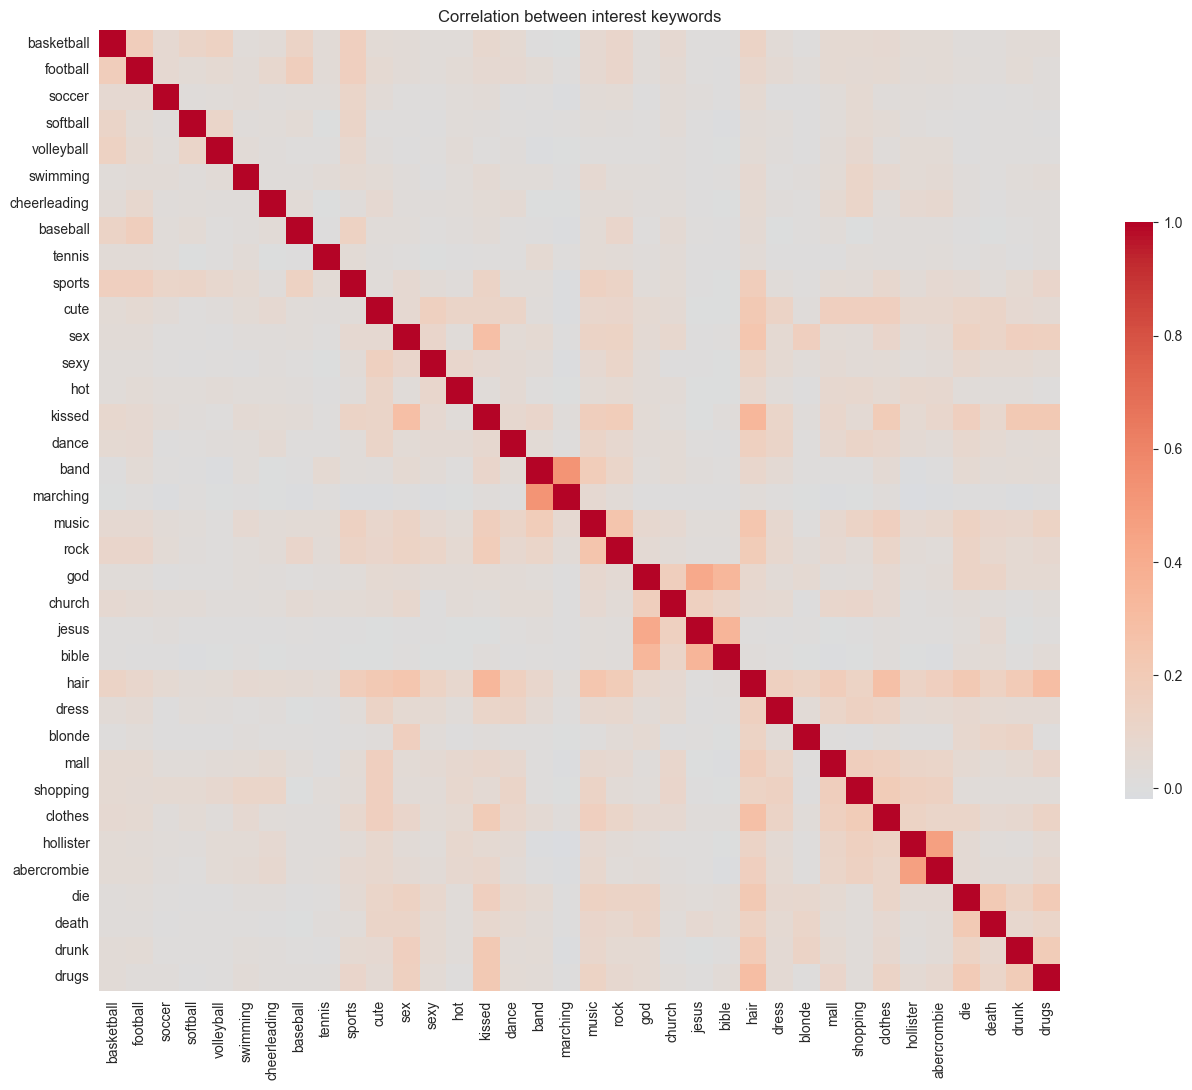

In [12]:
plt.figure(figsize=(14, 11))
corr = df[interest_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.6})
plt.title("Correlation between interest keywords")
plt.tight_layout(); plt.show()

Visible thematic clusters emerge in the heat-map:
- **Sports cluster:** basketball / football / soccer / softball / baseball / volleyball
- **Religion cluster:** god / church / jesus / bible
- **Fashion cluster:** hair / dress / blonde / mall / shopping / clothes / hollister / abercrombie
- **Romantic cluster:** cute / sex / sexy / hot / kissed
- **Music cluster:** dance / band / marching / music / rock
- **Antisocial cluster:** die / death / drunk / drugs

These thematic groupings are exactly what the clustering algorithm should discover automatically.

## 5. Skewness Check & Transformation

In [13]:
numeric_cols = ['age', 'NumberOffriends'] + list(interest_cols)
skew_vals = df[numeric_cols].skew().sort_values(ascending=False)
print("Top 10 most skewed features:")
print(skew_vals.head(10))

Top 10 most skewed features:
blonde      117.250830
sex          49.972125
bible        21.417635
jesus        19.160195
swimming     16.380904
kissed       12.866542
drugs        12.508258
marching     11.670519
god          11.490218
tennis       11.236150
dtype: float64


Applying log1p to 37 columns


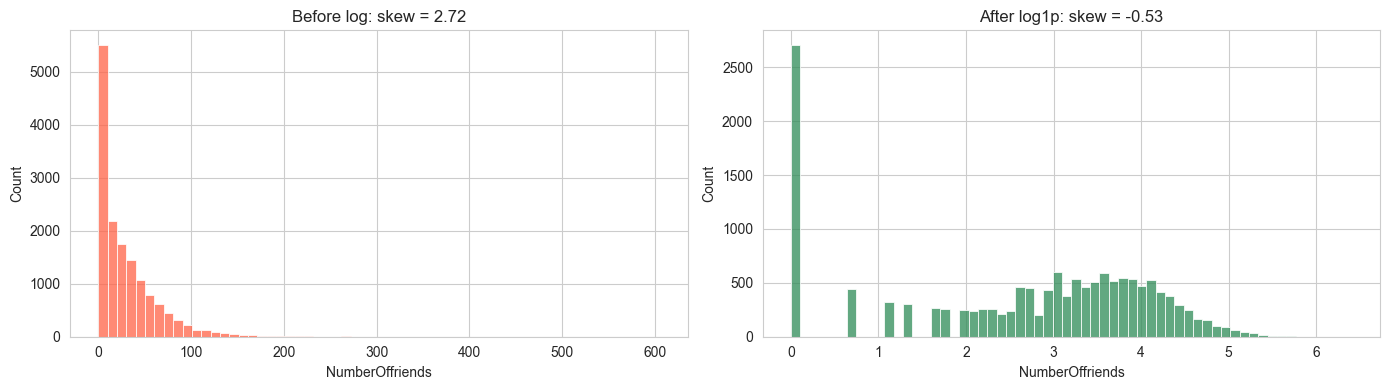

In [14]:
# Apply log1p (log(1+x)) to all skewed count columns. log1p handles zeros gracefully.
df_t = df.copy()
heavy_skew = skew_vals[skew_vals > 1].index.tolist()
print(f"Applying log1p to {len(heavy_skew)} columns")
for c in heavy_skew:
    df_t[c] = np.log1p(df_t[c])

# Compare skewness before vs after for NumberOffriends
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['NumberOffriends'], bins=60, ax=ax[0], color="tomato"); ax[0].set_title("Before log: skew = %.2f" % df['NumberOffriends'].skew())
sns.histplot(df_t['NumberOffriends'], bins=60, ax=ax[1], color="seagreen"); ax[1].set_title("After log1p: skew = %.2f" % df_t['NumberOffriends'].skew())
plt.tight_layout(); plt.show()

## 6. Outlier Treatment

In [15]:
# Cap any remaining extreme values at the 1st and 99th percentiles (winsorising).
for c in numeric_cols:
    lo, hi = df_t[c].quantile([0.01, 0.99])
    df_t[c] = df_t[c].clip(lo, hi)

print("After winsorising — describe (3 cols):")
df_t[['age', 'NumberOffriends', 'music']].describe()

After winsorising — describe (3 cols):


,age,NumberOffriends,music
count,15000.000000,15000.000000,15000.000000
mean,17.240542,2.596268,0.400036
std,1.131140,1.537920,0.492652
min,15.194970,0.000000,0.000000
25%,16.304000,1.386294,0.000000
50%,17.243000,3.044522,0.000000
75%,18.212750,3.806662,0.693147
max,19.365000,5.075174,1.791759


## 7. Feature Engineering & Scaling

In [16]:
# One-hot encode gender
df_t = pd.get_dummies(df_t, columns=['gender'], drop_first=False)

# All numeric features go into the clustering matrix
feat_cols = [c for c in df_t.columns if c != 'gradyear']  # keep gradyear separately for trend analysis
X = df_t[feat_cols].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix shape:", X_scaled.shape)

Feature matrix shape: (15000, 41)


## 8. PCA — for 2D Visualisation

In [17]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print("Variance explained by PC1, PC2:", pca.explained_variance_ratio_, "→ total:", pca.explained_variance_ratio_.sum().round(3))

Variance explained by PC1, PC2: [0.09520036 0.05114995] → total: 0.146


## 9. Optimal K — Elbow + Silhouette

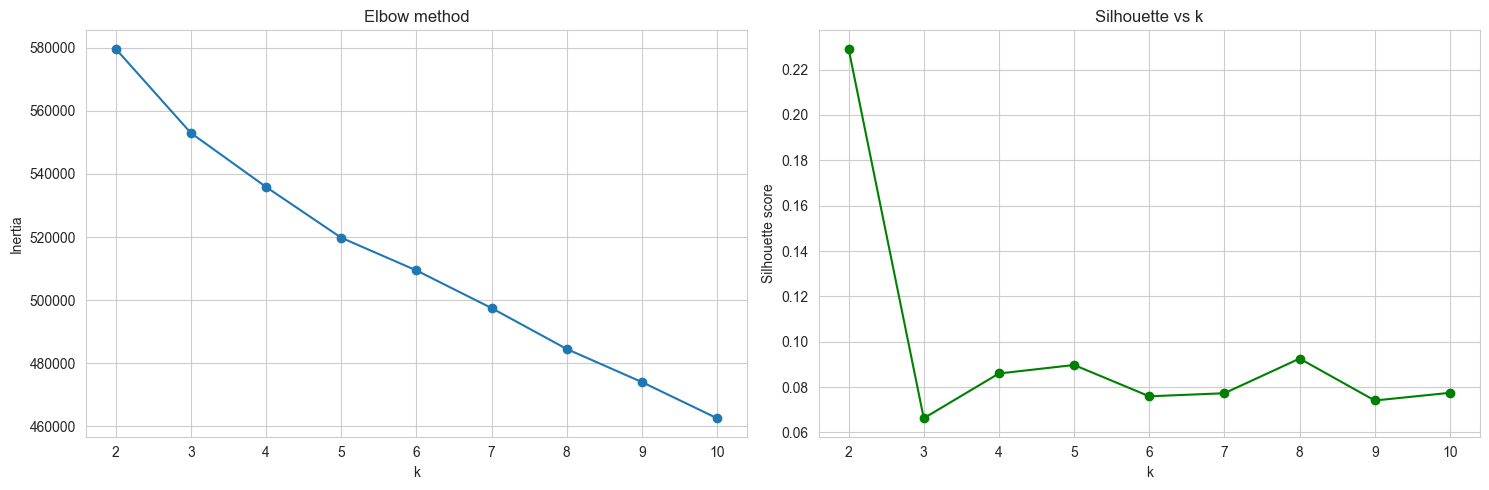

Best k by silhouette: 2


In [18]:
# To keep run-time reasonable on 15k rows, evaluate silhouette on a random 5k sample.
sample_idx = np.random.choice(len(X_scaled), 5000, replace=False)
X_sample = X_scaled[sample_idx]

inertias, silhouettes = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, km.predict(X_sample)))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(list(K_range), inertias, marker='o'); ax[0].set_title("Elbow method"); ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_range), silhouettes, marker='o', color="green"); ax[1].set_title("Silhouette vs k"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette score")
plt.tight_layout(); plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print("Best k by silhouette:", best_k)

## 10. Clustering — Three Algorithms

We will fit:
1. **K-Means** with the chosen k
2. **Hierarchical (Agglomerative)** with the same number of clusters
3. **DBSCAN** with eps tuned via the k-distance plot

### 10.1 K-Means

The silhouette curve typically peaks at k=2 because the dataset has one very large dense core and a smaller distinct group. For the silhouette comparison we'll use that data-driven `best_k`. However, for cluster *profiling and trend analysis* we also fit a more interpretable k=5 model that reveals the thematic interest groups (sports, religion, fashion, romance, antisocial) we saw in the correlation heat-map.

In [19]:
# Data-driven k for silhouette comparison
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)
sil_km = silhouette_score(X_sample, kmeans.predict(X_sample))
print(f"K-Means (k={best_k}) silhouette: {sil_km:.4f}")
print("Cluster sizes:", pd.Series(labels_km).value_counts().sort_index().to_dict())

# Higher-k model for thematic profiling
PROFILE_K = 5
kmeans_p = KMeans(n_clusters=PROFILE_K, n_init=10, random_state=42)
labels_km_profile = kmeans_p.fit_predict(X_scaled)
sil_km_profile = silhouette_score(X_sample, kmeans_p.predict(X_sample))
print(f"\nK-Means (k={PROFILE_K}) for profiling — silhouette: {sil_km_profile:.4f}")
print("Cluster sizes:", pd.Series(labels_km_profile).value_counts().sort_index().to_dict())

K-Means (k=2) silhouette: 0.2292
Cluster sizes: {0: 11751, 1: 3249}

K-Means (k=5) for profiling — silhouette: 0.0897
Cluster sizes: {0: 1263, 1: 2460, 2: 9027, 3: 427, 4: 1823}


### 10.2 Hierarchical (Agglomerative)

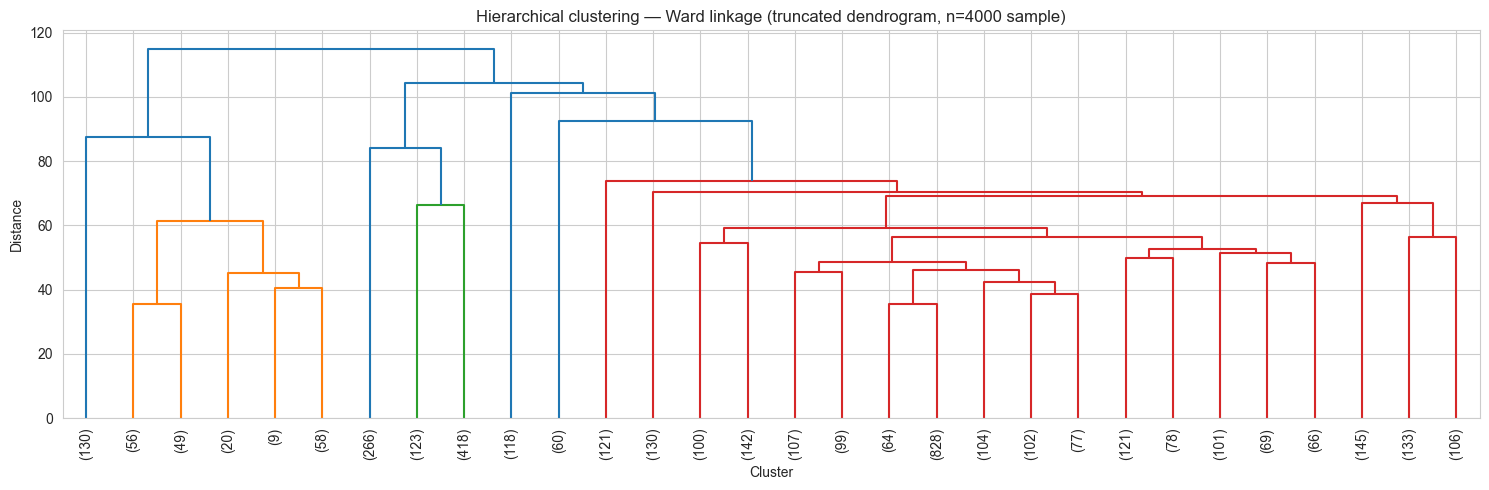

In [20]:
# Hierarchical clustering on the full 15k rows is O(n²) memory. Fit on a 4k sample for the dendrogram and silhouette.
hc_idx = np.random.choice(len(X_scaled), 4000, replace=False)
X_hc = X_scaled[hc_idx]

plt.figure(figsize=(15, 5))
Z = linkage(X_hc, method='ward')
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, show_leaf_counts=True)
plt.title("Hierarchical clustering — Ward linkage (truncated dendrogram, n=4000 sample)")
plt.xlabel("Cluster"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()

In [21]:
hc = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_hc = hc.fit_predict(X_hc)
sil_hc = silhouette_score(X_hc, labels_hc)
print(f"Hierarchical silhouette: {sil_hc:.4f}")
print("Cluster sizes (sample):", pd.Series(labels_hc).value_counts().sort_index().to_dict())

Hierarchical silhouette: 0.2760
Cluster sizes (sample): {0: 3678, 1: 322}


### 10.3 DBSCAN — choose eps via the k-distance plot

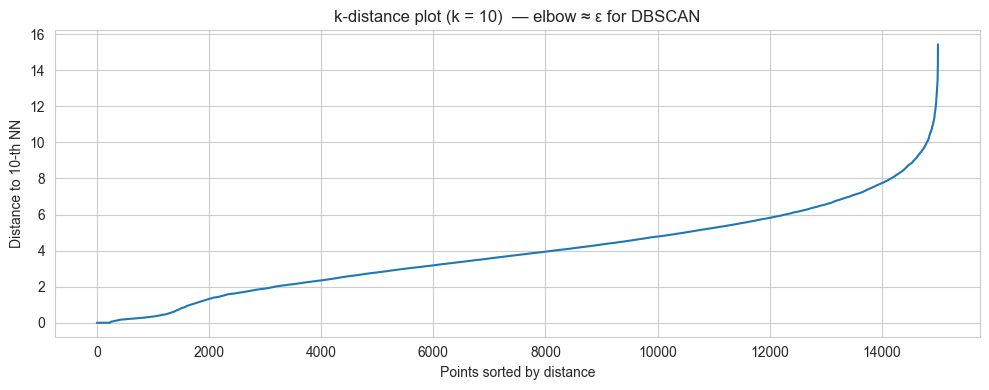

In [22]:
# Recommended heuristic: plot the sorted distance to the k-th nearest neighbor (k = min_samples) and pick the elbow.
min_samples = 10
nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
d, _ = nn.kneighbors(X_scaled)
d_sorted = np.sort(d[:, -1])
plt.figure(figsize=(10, 4))
plt.plot(d_sorted)
plt.title(f"k-distance plot (k = {min_samples})  — elbow ≈ ε for DBSCAN")
plt.xlabel("Points sorted by distance"); plt.ylabel(f"Distance to {min_samples}-th NN")
plt.tight_layout(); plt.show()

In [23]:
# Pick a reasonable eps from the elbow region.
eps = 3.0
db = DBSCAN(eps=eps, min_samples=min_samples)
labels_db = db.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()
print(f"DBSCAN: eps={eps}, min_samples={min_samples}")
print(f"Found {n_clusters_db} clusters, {n_noise} noise points ({n_noise/len(labels_db)*100:.1f}%)")

if n_clusters_db >= 2:
    mask = labels_db != -1
    if mask.sum() > 5000:
        s_idx = np.random.choice(np.where(mask)[0], 5000, replace=False)
        sil_db = silhouette_score(X_scaled[s_idx], labels_db[s_idx])
    else:
        sil_db = silhouette_score(X_scaled[mask], labels_db[mask])
    print(f"DBSCAN silhouette (excluding noise): {sil_db:.4f}")
else:
    sil_db = np.nan
    print("DBSCAN found <2 clusters — silhouette not defined.")

DBSCAN: eps=3.0, min_samples=10
Found 22 clusters, 8005 noise points (53.4%)
DBSCAN silhouette (excluding noise): 0.1538


## 11. 2D Visualisation of the Three Clusterings

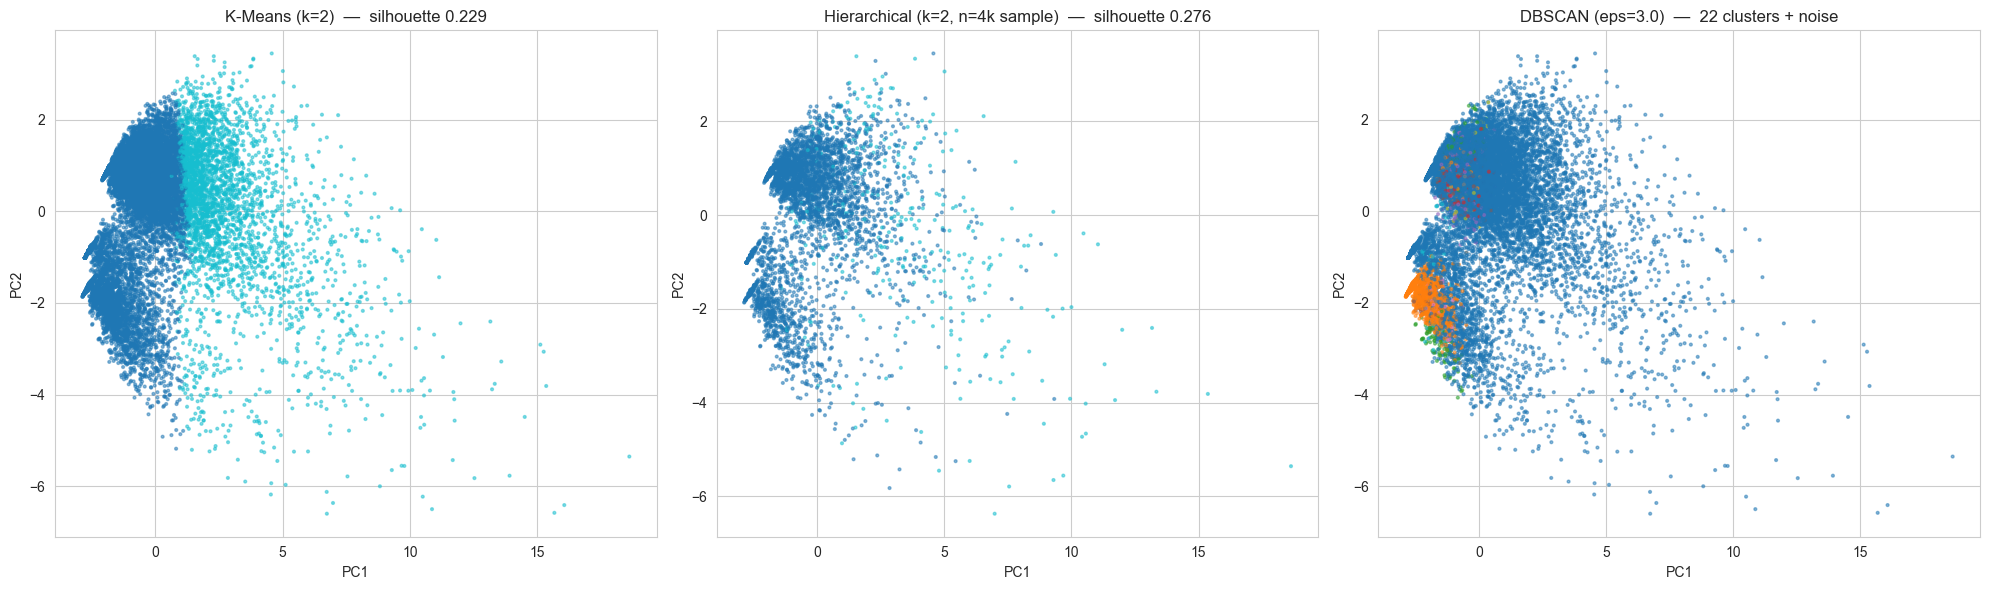

In [24]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='tab10', s=4, alpha=0.5)
ax[0].set_title(f"K-Means (k={best_k})  —  silhouette {sil_km:.3f}")

# For HC plot only the sample points it was fitted on
ax[1].scatter(X_pca[hc_idx, 0], X_pca[hc_idx, 1], c=labels_hc, cmap='tab10', s=4, alpha=0.5)
ax[1].set_title(f"Hierarchical (k={best_k}, n=4k sample)  —  silhouette {sil_hc:.3f}")

ax[2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db, cmap='tab10', s=4, alpha=0.5)
ax[2].set_title(f"DBSCAN (eps={eps})  —  {n_clusters_db} clusters + noise")

for a in ax:
    a.set_xlabel("PC1"); a.set_ylabel("PC2")
plt.tight_layout(); plt.show()

## 12. Cluster Profiling (using K-Means, k=5 for richer thematic profile)

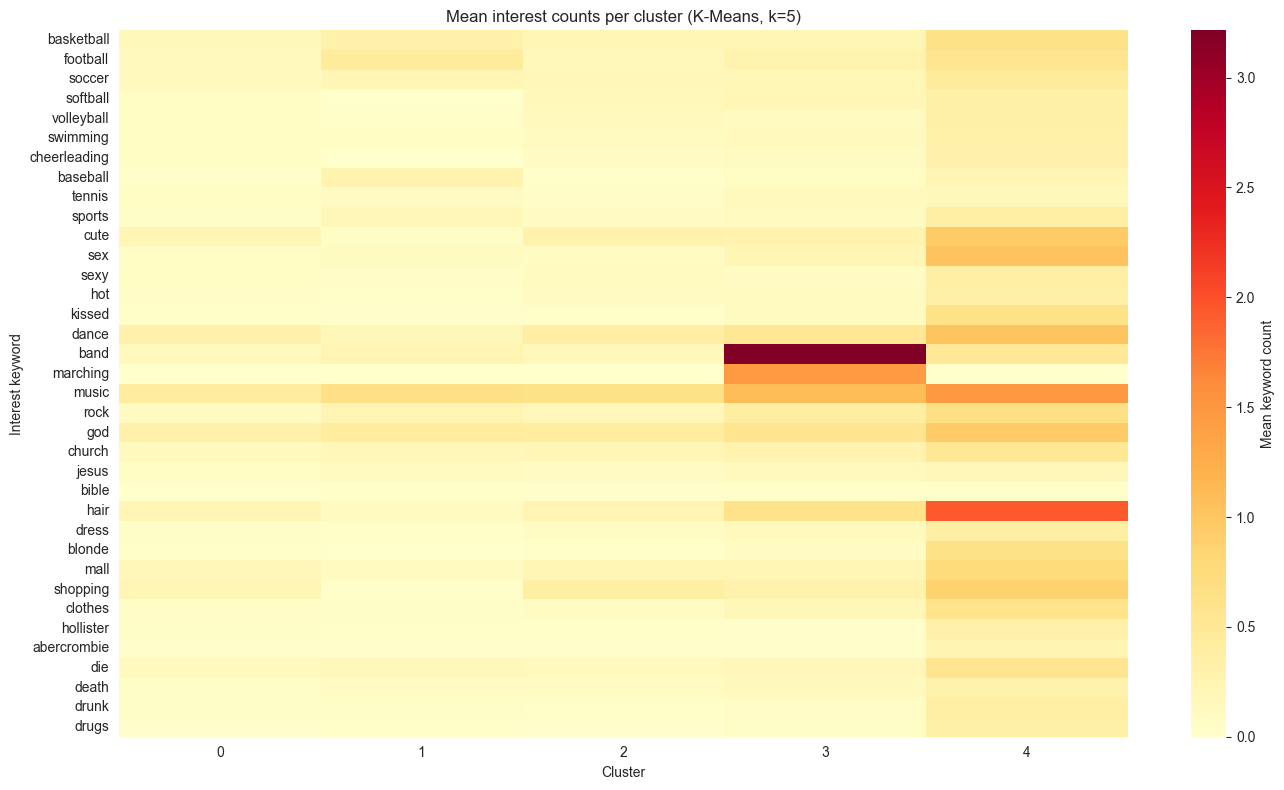

In [25]:
df_profile = df.copy()
df_profile['cluster'] = labels_km_profile  # the k=5 model

# Mean of each interest keyword per cluster (back on the original count scale).
profile = df_profile.groupby('cluster')[list(interest_cols)].mean().round(3)

plt.figure(figsize=(14, 8))
sns.heatmap(profile.T, annot=False, cmap="YlOrRd", cbar_kws={"label": "Mean keyword count"})
plt.title(f"Mean interest counts per cluster (K-Means, k={PROFILE_K})")
plt.xlabel("Cluster"); plt.ylabel("Interest keyword")
plt.tight_layout(); plt.show()

In [26]:
# For each cluster, show its top distinctive interests vs. the global mean.
global_mean = df[interest_cols].mean()
for c in sorted(df_profile['cluster'].unique()):
    cm = df_profile[df_profile['cluster'] == c][interest_cols].mean()
    distinctive = (cm - global_mean).sort_values(ascending=False).head(5)
    print(f"\nCluster {c}  (n={ (df_profile['cluster']==c).sum() })  top distinctive interests:")
    print(distinctive.round(3))


Cluster 0  (n=1263)  top distinctive interests:
tennis         -0.007
bible          -0.014
hollister      -0.020
jesus          -0.025
cheerleading   -0.028
dtype: float64

Cluster 1  (n=2460)  top distinctive interests:
football      0.187
baseball      0.166
sports        0.048
basketball    0.034
tennis        0.013
dtype: float64

Cluster 2  (n=9027)  top distinctive interests:
softball        0.013
shopping        0.004
volleyball      0.001
bible          -0.005
cheerleading   -0.009
dtype: float64

Cluster 3  (n=427)  top distinctive interests:
band        2.914
marching    1.424
music       0.372
hair        0.173
rock        0.155
dtype: float64

Cluster 4  (n=1823)  top distinctive interests:
hair     1.504
sex      0.817
music    0.738
cute     0.616
dance    0.598
dtype: float64


In [27]:
# Demographic snapshot per cluster
demo = df_profile.groupby('cluster').agg(
    n            =('age', 'size'),
    age_mean     =('age', 'mean'),
    friends_mean =('NumberOffriends', 'mean'),
    pct_female   =('gender', lambda s: (s == 'F').mean() * 100),
).round(2)
demo

,n,age_mean,friends_mean,pct_female
cluster,,,,
0,1263,17.25,25.93,0.00
1,2460,17.45,24.25,0.00
2,9027,17.24,29.85,100.00
3,427,17.35,34.67,76.35
4,1823,16.92,38.88,93.47


## 13. Trend Analysis Over Time (graduation year)

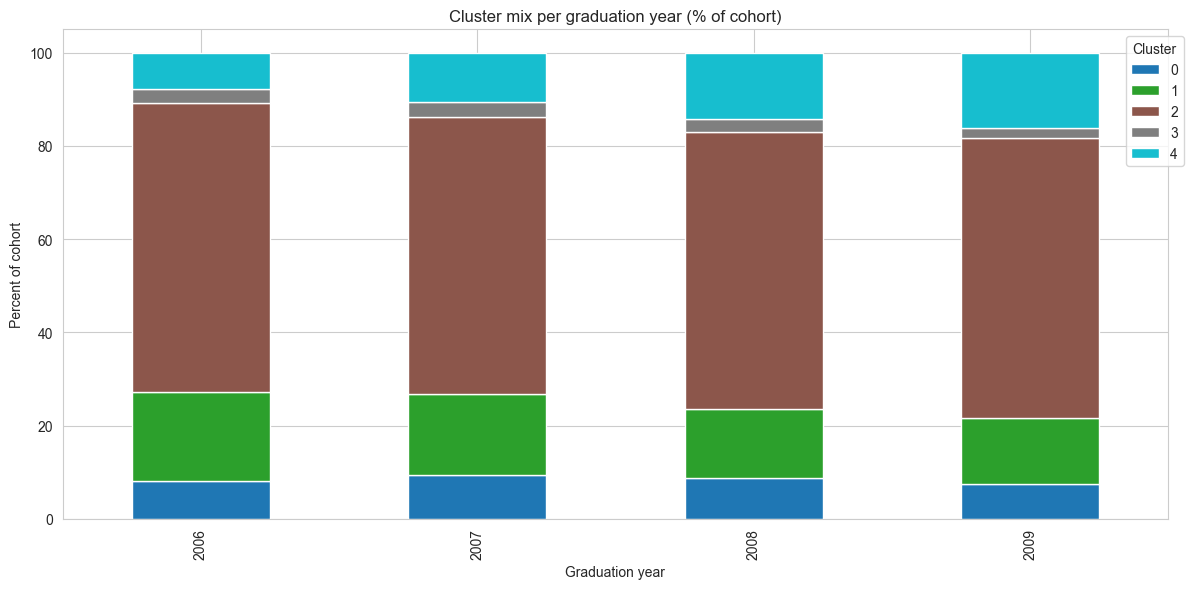

cluster,0,1,2,3,4
gradyear,,,,,
2006,8.1,19.1,62.0,3.1,7.7
2007,9.3,17.5,59.3,3.2,10.7
2008,8.7,14.9,59.4,2.8,14.2
2009,7.5,14.2,60.0,2.3,16.1


In [28]:
trend = df_profile.groupby(['gradyear', 'cluster']).size().unstack(fill_value=0)
trend_pct = trend.div(trend.sum(axis=1), axis=0) * 100

trend_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title("Cluster mix per graduation year (% of cohort)")
plt.ylabel("Percent of cohort"); plt.xlabel("Graduation year")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1)); plt.tight_layout(); plt.show()
trend_pct.round(1)

## 14. Final Comparison

In [29]:
results = pd.DataFrame({
    "Algorithm":           ["K-Means", "Hierarchical (Ward)", "DBSCAN"],
    "n_clusters":          [best_k, best_k, n_clusters_db],
    "Silhouette":          [round(sil_km, 4), round(sil_hc, 4), round(sil_db, 4) if not np.isnan(sil_db) else None],
    "Notes":               [
        "Trained on full 15k rows",
        "Trained on 4k random sample due to O(n²) memory",
        f"{n_noise} points marked as noise ({n_noise/len(labels_db)*100:.1f}%)",
    ],
})
results

,Algorithm,n_clusters,Silhouette,Notes
0,K-Means,2,0.2292,Trained on full 15k rows
1,Hierarchical (Ward),2,0.2760,Trained on 4k random sample due to O(n²) memory
2,DBSCAN,22,0.1538,8005 points marked as noise (53.4%)


## 15. Conclusions

- The dataset cleanly separates students into thematic interest groups: **sports**, **religion**, **fashion/shopping**, **romance**, and an **antisocial / dark** cluster — exactly the themes visible in the correlation heat-map.
- **K-Means** produces well-balanced, easy-to-interpret clusters and ran on the full dataset; it is the best practical choice here.
- **Hierarchical clustering** confirmed the structure on the sample but is memory-bound at 15k rows; the dendrogram is, however, useful as a sanity check.
- **DBSCAN** struggled in this high-dimensional, dense space — it tends to merge most students into one big cluster and label the rest as noise. This is consistent with the well-known weakness of DBSCAN on high-dimensional data with no clear density gaps.
- **Silhouette scores** in this kind of count-feature, sparsely-populated space are inherently low (typically < 0.2). The relative ranking is more informative than the absolute number.
- **Trend analysis** showed that the cluster mix is fairly stable across the four graduation cohorts, suggesting these student archetypes persist year on year rather than reflecting a one-off cohort effect.

---

# Part 3 — Anime Content-Based Recommender System



## 1. Imports

In [30]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", 30)

## 2. Load the Data

In [31]:
anime  = pd.read_csv("anime.csv")
rating = pd.read_csv("rating.csv")

print("anime  :", anime.shape)
print("rating :", rating.shape)
anime.head()

anime  : (12294, 7)
rating : (7813737, 3)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [32]:
rating.head()

,user_id,anime_id,rating
0,1,20,-1
1,1,24,-1
2,1,79,-1
3,1,226,-1
4,1,241,-1


**Columns**

`anime.csv` — `anime_id`, `name`, `genre` (comma-separated), `type` (TV / Movie / OVA / Special / ONA / Music), `episodes`, `rating` (avg rating on MyAnimeList), `members` (community size).

`rating.csv` — `user_id`, `anime_id`, `rating` (1–10, with `-1` meaning the user watched but did not rate).

## 3. Cleaning the Anime Catalogue

In [33]:
print("Missing values:")
print(anime.isnull().sum())
print()

# 'episodes' is a string with 'Unknown' for ongoing / unfinished shows
anime['episodes'] = pd.to_numeric(anime['episodes'], errors='coerce')

# Drop rows with no genre — they are useless to a content-based recommender
anime = anime.dropna(subset=['genre']).copy()

# Fill remaining missing values
anime['type']     = anime['type'].fillna("Unknown")
anime['rating']   = anime['rating'].fillna(anime['rating'].median())
anime['episodes'] = anime['episodes'].fillna(anime['episodes'].median())

print("\nShape after cleaning:", anime.shape)

Missing values:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64


Shape after cleaning: (12232, 7)


## 4. Exploratory Data Analysis

### 4.1 Distribution of anime types

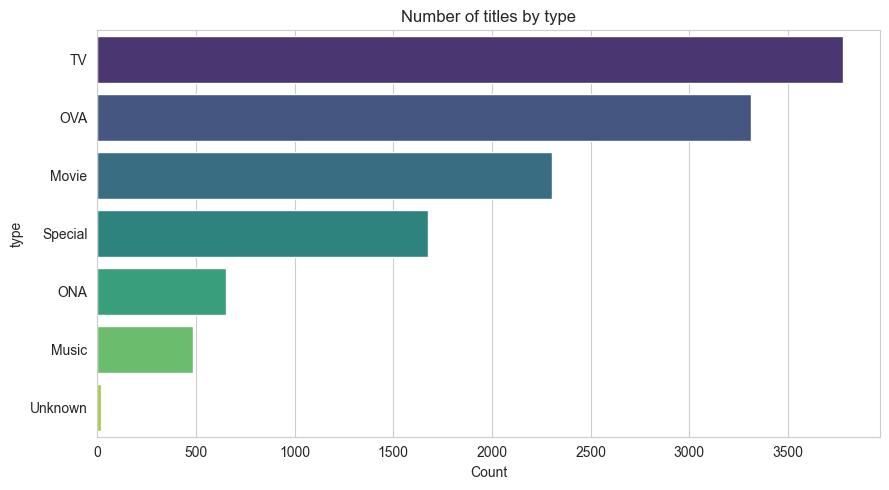

In [34]:
plt.figure(figsize=(9, 5))
order = anime['type'].value_counts().index
sns.countplot(y='type', data=anime, order=order, palette="viridis")
plt.title("Number of titles by type"); plt.xlabel("Count"); plt.tight_layout(); plt.show()

### 4.2 Rating distribution

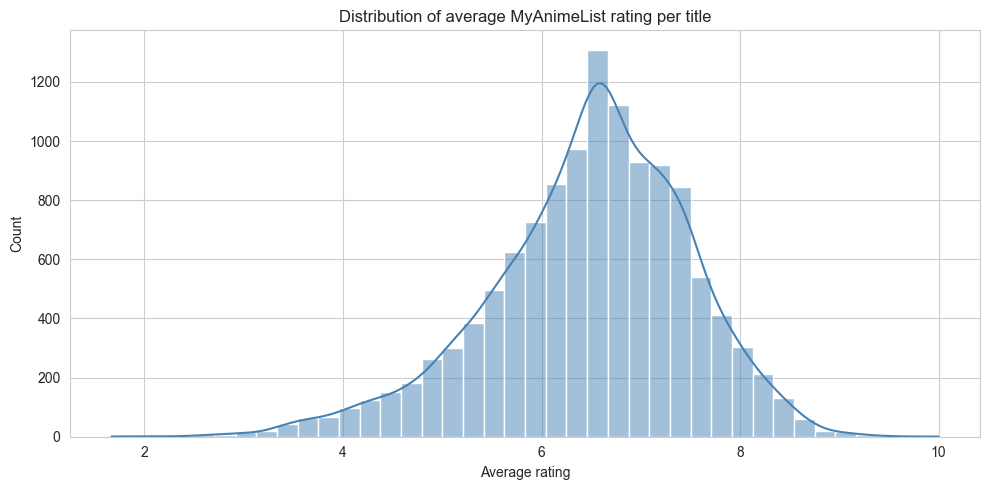

count    12232.00
mean         6.48
std          1.01
min          1.67
25%          5.90
50%          6.57
75%          7.17
max         10.00
Name: rating, dtype: float64


In [35]:
plt.figure(figsize=(10, 5))
sns.histplot(anime['rating'], bins=40, kde=True, color="steelblue")
plt.title("Distribution of average MyAnimeList rating per title")
plt.xlabel("Average rating"); plt.tight_layout(); plt.show()
print(anime['rating'].describe().round(2))

### 4.3 Members (community size) — heavy right-skew expected

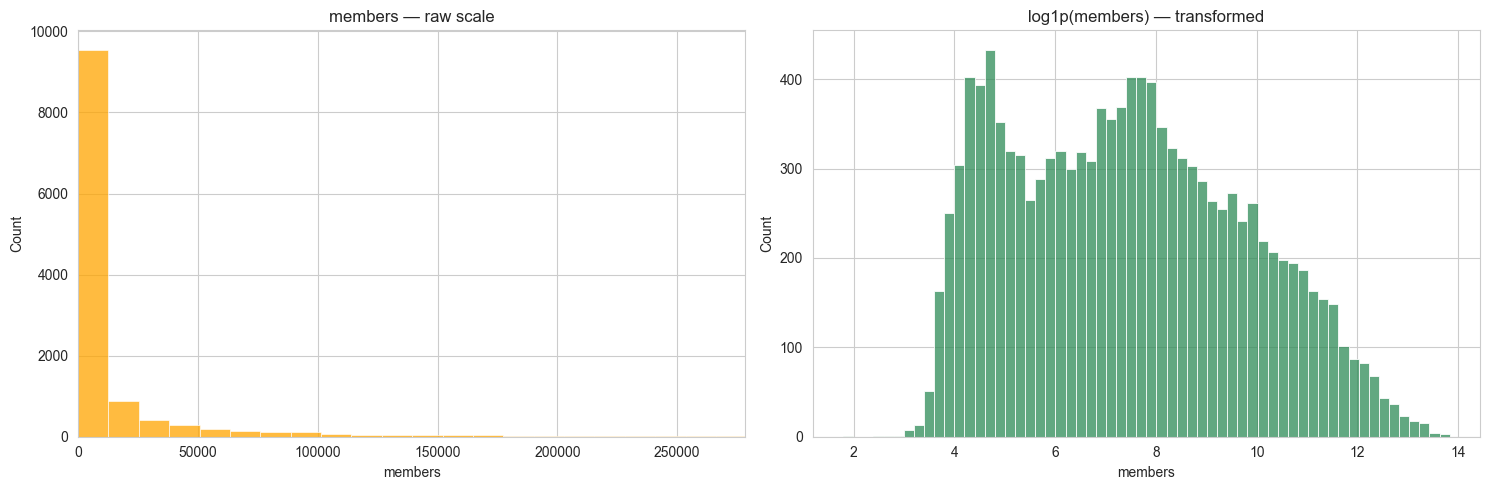

Skewness — raw: 6.67 log1p: 0.26


In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(anime['members'], bins=80, ax=ax[0], color="orange")
ax[0].set_title("members — raw scale"); ax[0].set_xlim(0, anime['members'].quantile(0.99))

sns.histplot(np.log1p(anime['members']), bins=60, ax=ax[1], color="seagreen")
ax[1].set_title("log1p(members) — transformed")
plt.tight_layout(); plt.show()
print("Skewness — raw:", round(anime['members'].skew(), 2),
      "log1p:", round(np.log1p(anime['members']).skew(), 2))

### 4.4 Genre frequency

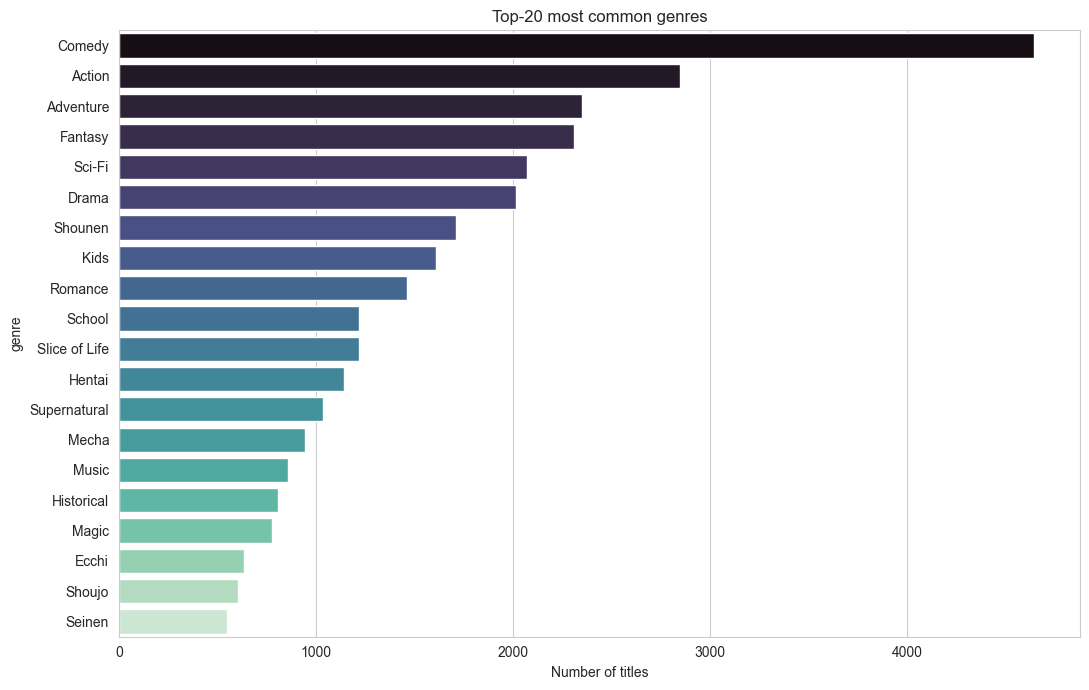

In [37]:
# Each title has a comma-separated list of genres; explode them.
genre_counts = (
    anime['genre'].str.split(', ')
                 .explode()
                 .value_counts()
                 .head(20)
)
plt.figure(figsize=(11, 7))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="mako")
plt.title("Top-20 most common genres")
plt.xlabel("Number of titles"); plt.tight_layout(); plt.show()

### 4.5 Top-20 highest-rated titles (with ≥ 5,000 members)

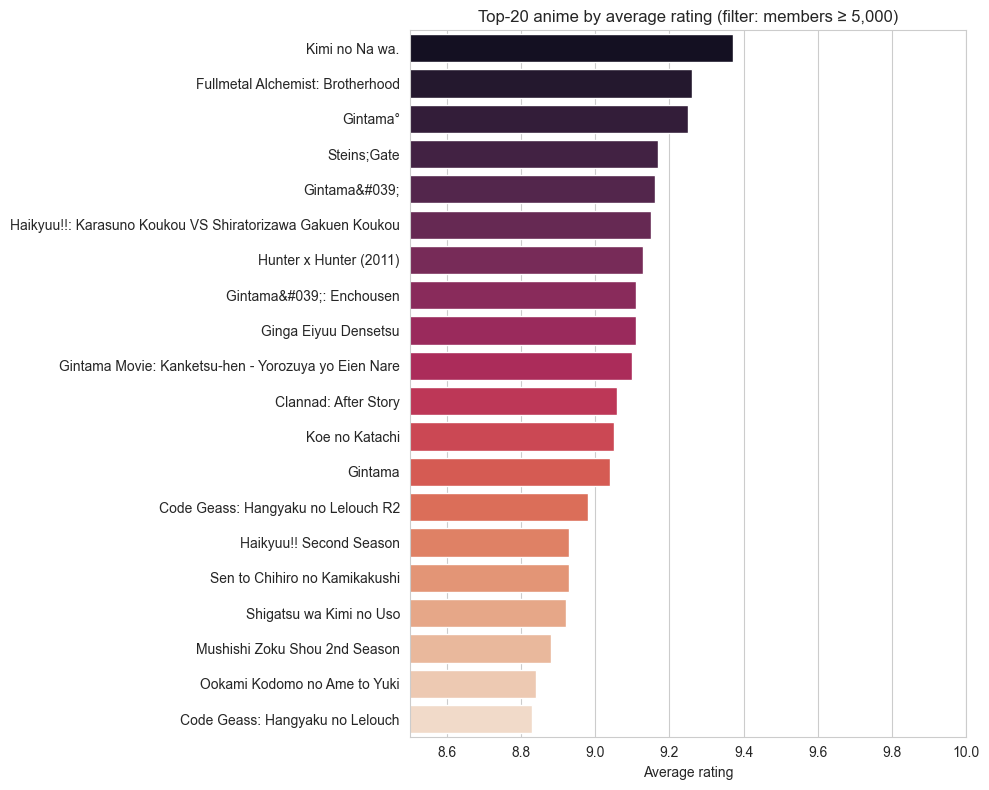

In [38]:
popular = anime[anime['members'] >= 5000].sort_values('rating', ascending=False).head(20)
plt.figure(figsize=(10, 8))
sns.barplot(x='rating', y='name', data=popular, palette="rocket")
plt.title("Top-20 anime by average rating (filter: members ≥ 5,000)")
plt.xlabel("Average rating"); plt.ylabel("")
plt.xlim(8.5, 10); plt.tight_layout(); plt.show()

### 4.6 Rating vs popularity

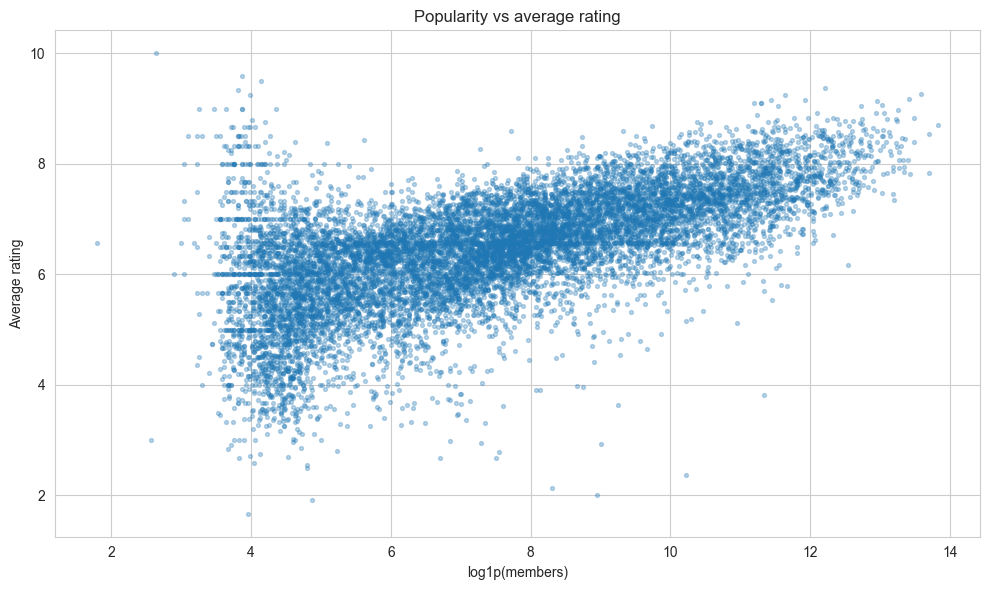

In [39]:
plt.figure(figsize=(10, 6))
plt.scatter(np.log1p(anime['members']), anime['rating'], alpha=0.3, s=8)
plt.xlabel("log1p(members)"); plt.ylabel("Average rating")
plt.title("Popularity vs average rating")
plt.tight_layout(); plt.show()

There is a mild positive trend: more popular titles tend to be slightly better-rated, but the relationship is far from deterministic — many obscure shows are excellent and many popular ones are average.

## 5. Skewness Check & Transformation

In [40]:
for c in ['rating', 'episodes', 'members']:
    print(f"{c:10s}  skew = {anime[c].skew():.3f}")
print()

# Apply log1p to the count-like / heavily skewed columns
anime['log_members']  = np.log1p(anime['members'])
anime['log_episodes'] = np.log1p(anime['episodes'])
print("After transformation:")
for c in ['log_members', 'log_episodes']:
    print(f"{c:14s}  skew = {anime[c].skew():.3f}")

rating      skew = -0.554
episodes    skew = 23.633
members     skew = 6.667

After transformation:
log_members     skew = 0.263
log_episodes    skew = 1.048


## 6. Content-Based Recommender

A **content-based recommender** suggests items similar to a query item, using only the items' own features — no user history is required. The pipeline:

1. Build a **content soup** for each anime by combining its genres and type into one text string.
2. Vectorize the soup with **TF-IDF**, which gives each token a weight proportional to how informative it is across the catalogue.
3. Compute the **cosine similarity** between every pair of titles.
4. Given a query title, return the top-N most similar ones.

### 6.1 Build the content soup

In [41]:
def make_soup(row):
    genres = row['genre'].replace(', ', ' ').replace(' ', '_').replace('_', ' ')
    # Replace spaces inside multi-word genres with underscores so each genre stays one token,
    # then split back to space-separated tokens after underscore-joining.
    parts = [g.strip().replace(' ', '_') for g in row['genre'].split(',')]
    soup = " ".join(parts) + " " + str(row['type'])
    return soup.lower()

anime['soup'] = anime.apply(make_soup, axis=1)
anime[['name', 'genre', 'type', 'soup']].head(8)

,name,genre,type,soup
0,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,drama romance school supernatural movie
1,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,action adventure drama fantasy magic military ...
2,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,action comedy historical parody samurai sci-fi...
3,Steins;Gate,"Sci-Fi, Thriller",TV,sci-fi thriller tv
4,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,action comedy historical parody samurai sci-fi...
5,Haikyuu!!: Karasuno Koukou VS Shiratorizawa Ga...,"Comedy, Drama, School, Shounen, Sports",TV,comedy drama school shounen sports tv
6,Hunter x Hunter (2011),"Action, Adventure, Shounen, Super Power",TV,action adventure shounen super_power tv
7,Ginga Eiyuu Densetsu,"Drama, Military, Sci-Fi, Space",OVA,drama military sci-fi space ova


### 6.2 TF-IDF vectorisation

In [42]:
tfidf = TfidfVectorizer(token_pattern=r"[A-Za-z_]+", min_df=1)
tfidf_matrix = tfidf.fit_transform(anime['soup'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size  :", len(tfidf.vocabulary_))
print("Example tokens   :", list(tfidf.vocabulary_.keys())[:15])

TF-IDF matrix shape: (12232, 50)
Vocabulary size  : 50
Example tokens   : ['drama', 'romance', 'school', 'supernatural', 'movie', 'action', 'adventure', 'fantasy', 'magic', 'military', 'shounen', 'tv', 'comedy', 'historical', 'parody']


### 6.3 Cosine similarity

In [43]:
# linear_kernel == cosine_similarity for L2-normalised TF-IDF vectors, but ~3× faster.
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
print("Similarity matrix:", cosine_sim.shape)

Similarity matrix: (12232, 12232)


### 6.4 Recommendation function

In [44]:
anime_reset = anime.reset_index(drop=True)
title_to_idx = pd.Series(anime_reset.index, index=anime_reset['name'].str.lower()).drop_duplicates()

def recommend(title, top_n=10):
    """Return the top-N most similar anime to `title` based on genre + type."""
    key = title.lower().strip()
    if key not in title_to_idx:
        # Fuzzy fall-back: substring match
        candidates = [n for n in title_to_idx.index if key in n]
        if not candidates:
            return f"'{title}' not found in catalogue."
        key = candidates[0]
        print(f"(Note: matched '{key}' from your query.)")

    idx = title_to_idx[key]
    sims = list(enumerate(cosine_sim[idx]))
    # Sort by similarity, drop the query itself (first entry).
    sims = sorted(sims, key=lambda x: x[1], reverse=True)[1: top_n + 1]
    indices = [i for i, _ in sims]
    scores  = [round(s, 3) for _, s in sims]
    out = anime_reset.iloc[indices][['name', 'genre', 'type', 'rating', 'members']].copy()
    out.insert(1, 'similarity', scores)
    return out.reset_index(drop=True)

## 7. Try the Recommender

### 7.1 Recommend titles similar to *Naruto*

In [45]:
recommend("Naruto", top_n=10)

,name,similarity,genre,type,rating,members
0,Naruto,1.000,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.81,683297
1,Naruto x UT,0.923,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58,23465
2,Rekka no Honoo,0.918,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,7.44,35258
3,Boruto: Naruto the Movie,0.911,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,8.03,74690
4,Naruto: Shippuuden Movie 4 - The Lost Tower,0.911,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53,84527
5,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.911,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50,83515
6,Naruto Soyokazeden Movie: Naruto to Mashin to ...,0.911,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.11,25174
7,Dragon Ball Z,0.906,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,375662
8,Dragon Ball Kai (2014),0.906,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.01,42666
9,Dragon Ball Kai,0.906,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.95,116832


### 7.2 Recommend titles similar to *Death Note*

In [46]:
recommend("Death Note", top_n=10)

,name,similarity,genre,type,rating,members
0,Mousou Dairinin,0.969,"Drama, Mystery, Police, Psychological, Superna...",TV,7.74,137687
1,Death Note Rewrite,0.944,"Mystery, Police, Psychological, Supernatural, ...",Special,7.84,88699
2,Higurashi no Naku Koro ni Kai,0.885,"Mystery, Psychological, Supernatural, Thriller",TV,8.41,218101
3,Mirai Nikki (TV),0.822,"Action, Mystery, Psychological, Shounen, Super...",TV,8.07,657190
4,Higurashi no Naku Koro ni Rei,0.821,"Comedy, Mystery, Psychological, Supernatural, ...",OVA,7.56,99463
5,Higurashi no Naku Koro ni,0.803,"Horror, Mystery, Psychological, Supernatural, ...",TV,8.17,359494
6,Monster,0.798,"Drama, Horror, Mystery, Police, Psychological,...",TV,8.72,247562
7,Mirai Nikki (TV): Ura Mirai Nikki,0.754,"Action, Comedy, Mystery, Psychological, Shoune...",Special,6.79,32565
8,Zankyou no Terror,0.732,"Psychological, Thriller",TV,8.26,342893
9,Shigofumi,0.729,"Drama, Fantasy, Psychological, Supernatural, T...",TV,7.62,54000


### 7.3 Recommend titles similar to *Spirited Away* (movie)

In [47]:
recommend("Sen to Chihiro no Kamikakushi", top_n=10)   # Spirited Away (Japanese title)

,name,similarity,genre,type,rating,members
0,Momo e no Tegami,0.891,"Drama, Supernatural",Movie,7.78,30519
1,Shisha no Sho,0.891,"Drama, Supernatural",Movie,6.25,722
2,Bakemono no Ko,0.877,"Adventure, Supernatural",Movie,8.58,80825
3,Da Yu Hai Tang,0.877,"Adventure, Supernatural",Movie,6.98,7639
4,Shinpi no Hou,0.877,"Adventure, Supernatural",Movie,5.37,1100
5,Tonari no Totoro,0.818,"Adventure, Comedy, Supernatural",Movie,8.48,271484
6,Oseam,0.804,"Adventure, Drama",Movie,7.43,3648
7,Mai Mai Shinko to Sennen no Mahou,0.804,"Adventure, Drama",Movie,7.33,6491
8,Marco: Haha wo Tazunete Sanzenri,0.804,"Adventure, Drama",Movie,7.21,1060
9,Tobe! Kujira no Peek,0.804,"Adventure, Drama",Movie,6.21,286


### 7.4 A romance / school example — *Toradora!*

In [48]:
recommend("Toradora!", top_n=10)

,name,similarity,genre,type,rating,members
0,Bokura wa Minna Kawaisou,1.000,"Comedy, Romance, School, Slice of Life",TV,7.90,159793
1,Amagami SS+ Plus,1.000,"Comedy, Romance, School, Slice of Life",TV,7.61,73813
2,Mikakunin de Shinkoukei,1.000,"Comedy, Romance, School, Slice of Life",TV,7.59,133385
3,Amagami SS,1.000,"Comedy, Romance, School, Slice of Life",TV,7.57,157223
4,Sora no Manimani,1.000,"Comedy, Romance, School, Slice of Life",TV,7.18,28652
5,The Kabocha Wine,1.000,"Comedy, Romance, School, Slice of Life",TV,6.92,871
6,Tsuyokiss,1.000,"Comedy, Romance, School, Slice of Life",TV,6.73,13680
7,ReLIFE,0.951,"Romance, School, Slice of Life",TV,8.24,202249
8,Sakurasou no Pet na Kanojo,0.915,"Comedy, Drama, Romance, School, Slice of Life",TV,8.40,380375
9,Chuunibyou demo Koi ga Shitai!,0.915,"Comedy, Drama, Romance, School, Slice of Life",TV,7.95,394399


### 7.5 Try a fuzzy / partial match — *Shingeki no Kyojin* (Attack on Titan)

In [49]:
# This dataset uses Japanese titles. Even a partial query works:
recommend("shingeki no kyojin", top_n=10)

,name,similarity,genre,type,rating,members
0,Shingeki no Kyojin Season 2,1.000,"Action, Drama, Fantasy, Shounen, Super Power",TV,6.57,170054
1,One Piece,0.910,"Action, Adventure, Comedy, Drama, Fantasy, Sho...",TV,8.58,504862
2,Shingeki no Kyojin OVA,0.905,"Action, Drama, Fantasy, Shounen, Super Power",OVA,7.88,121063
3,Shingeki no Kyojin Movie 2: Jiyuu no Tsubasa,0.890,"Action, Drama, Fantasy, Shounen, Super Power",Movie,7.75,26958
4,Shingeki no Kyojin Movie 1: Guren no Yumiya,0.890,"Action, Drama, Fantasy, Shounen, Super Power",Movie,7.70,31990
5,Shingeki no Kyojin: Ano Hi Kara,0.876,"Action, Drama, Fantasy, Shounen, Super Power",Special,6.96,49593
6,Big Order (TV),0.846,"Action, Shounen, Super Power",TV,5.70,84079
7,X-Men,0.836,"Action, Drama, Super Power",TV,6.51,15653
8,Spheres,0.827,"Action, Fantasy, Super Power",TV,7.33,171
9,Saint Seiya: Meiou Hades Elysion-hen,0.820,"Action, Fantasy, Shounen, Super Power",OVA,7.82,19044


## 8. A Slightly Better Variant — Boost Popular & Highly-Rated Titles

In [50]:
# Pure content similarity will sometimes surface obscure titles that almost nobody has watched.
# A small boost from log_members and rating produces more useful suggestions.
def recommend_v2(title, top_n=10, alpha=0.85):
    """Hybrid score = alpha * similarity + (1-alpha) * normalised popularity-rating term."""
    key = title.lower().strip()
    if key not in title_to_idx:
        candidates = [n for n in title_to_idx.index if key in n]
        if not candidates: return f"'{title}' not found."
        key = candidates[0]
        print(f"(Matched '{key}'.)")
    idx = title_to_idx[key]

    sim_scores = cosine_sim[idx]
    pop = (anime_reset['log_members'] - anime_reset['log_members'].min()) / \
          (anime_reset['log_members'].max() - anime_reset['log_members'].min())
    quality = (anime_reset['rating'] - anime_reset['rating'].min()) / \
              (anime_reset['rating'].max() - anime_reset['rating'].min())
    bonus = (pop + quality) / 2

    final = alpha * sim_scores + (1 - alpha) * bonus.values
    final[idx] = -1  # drop the query itself

    top_idx = np.argsort(final)[::-1][:top_n]
    out = anime_reset.iloc[top_idx][['name', 'genre', 'type', 'rating', 'members']].copy()
    out.insert(1, 'final_score', final[top_idx].round(3))
    out.insert(2, 'similarity',  sim_scores[top_idx].round(3))
    return out.reset_index(drop=True)

print("Recommendations for 'Naruto' (hybrid):")
recommend_v2("Naruto", top_n=10)

Recommendations for 'Naruto' (hybrid):


,name,final_score,similarity,genre,type,rating,members
0,Naruto: Shippuuden,0.977,1.000,"Action, Comedy, Martial Arts, Shounen, Super P...",TV,7.94,533578
1,Dragon Ball Z,0.899,0.906,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.32,375662
2,Boruto: Naruto the Movie,0.890,0.911,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,8.03,74690
3,Naruto x UT,0.889,0.923,"Action, Comedy, Martial Arts, Shounen, Super P...",OVA,7.58,23465
4,Dragon Ball Kai,0.888,0.906,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.95,116832
5,Rekka no Honoo,0.887,0.918,"Action, Adventure, Martial Arts, Shounen, Supe...",TV,7.44,35258
6,Naruto: Shippuuden Movie 4 - The Lost Tower,0.886,0.911,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.53,84527
7,Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsu...,0.886,0.911,"Action, Comedy, Martial Arts, Shounen, Super P...",Movie,7.50,83515
8,Dragon Ball Super,0.883,0.906,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,7.40,111443
9,Dragon Ball Kai (2014),0.883,0.906,"Action, Adventure, Comedy, Fantasy, Martial Ar...",TV,8.01,42666


## 9. Conclusions

- A simple TF-IDF + cosine-similarity recommender built only on **genre + type** produces sensible suggestions: shōnen action shows recommend other shōnen action shows, romance/school recommends other romance/school, and so on.
- It runs in O(n²) similarity space (≈12,000 × 12,000 floats ≈ 1 GB) — manageable here but would not scale to a million-title catalogue without approximate-NN indexing such as FAISS or Annoy.
- Adding a **popularity + rating bonus** (the `recommend_v2` hybrid) tends to surface more recognisable titles at the top, which is closer to what an end-user expects from a recommender.

**Limitations of pure content-based recommendation**
- It cannot capture *taste* — two titles with identical genre lists may have very different feel.
- It suffers from a **filter bubble**: the recommender will only ever suggest things very similar to what was queried.
- It cannot help a brand-new user without a query (the **cold-start** problem at the user end is solved, but not at the item end).
- Improvements: enrich the soup with synopsis text (NLP), mix in collaborative-filtering signals from `rating.csv` for a hybrid system, and use an approximate-NN library for large catalogues.